# Auditability Spine: KG-Guided Repair + Benjamini-Hochberg Multiplicity (demo)

**Artifact:** *Expanded KG-Repair + Member-Labeling Auditability Spine for SAE-Latent Cluster Units*
(iter-4, experiment-1).

This artifact treats sparse-autoencoder (SAE) latents as a learned knowledge representation and
groups them into **cluster-level units** (a parent *anchor* latent + its *absorber* latents). When a
sub-context (e.g. the country *Georgia*, or the first-letter word *that*) gets **absorbed** into a
specialised latent, the parent anchor develops a *recall hole*. The method **names a covering
absorber per sub-context purely on a selection split**, **adds** it back to the anchor, and
**measures** recall recovery on held-out windows against a *random-addition control*.

The full pipeline encodes `gemma-2-2b` residuals through a frozen Gemma-Scope L12/16k JumpReLU SAE on
a **GPU** — too heavy for a 10-minute Colab demo. This notebook reproduces the **load-bearing,
CPU-only statistical core** from the pre-computed repair measurements:

> **MULTIPLICITY** — Benjamini-Hochberg FDR ≤ 0.05 across **all 69** KG-guided repair variants
> (three concept families: spelling, homograph-taxonomic, numeric), cross-checked against
> `statsmodels`, plus a paired bootstrap on the per-repair KG gains.

We load the 69 repair rows (each carrying its one-sided p-value and gain) from GitHub, re-run the
exact BH procedure from `method.py`, and reproduce the published result: **30 repairs survive
FDR ≤ 0.05** (spelling 14 / homograph-taxonomic 6 / numeric 10).

In [1]:
# --- install dependencies (Colab + local Jupyter compatible) ---
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# All packages used here are pre-installed on Colab -> install ONLY when NOT on Colab,
# pinned to Colab's exact versions so a local run mirrors the Colab environment.
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0', 'statsmodels==0.14.6')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# --- imports (subset of method.py's import block + matplotlib for the demo) ---
import os, sys, json, time
from collections import defaultdict, Counter

import numpy as np
import matplotlib.pyplot as plt

In [3]:
# --- data loading: GitHub raw URL with local fallback (Colab-friendly) ---
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-7ee30c-catching-silent-feature-absorption-in-fr/main/round-4/experiment-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print("description:", data["description"][:120], "...")
print("thresholds :", data["thresholds"])
print("n repair rows:", len(data["kg_repair_loop"]))
print("example row  :")
print(json.dumps(data["kg_repair_loop"][0], indent=1))

description: Curated subset for the demo: the FULL kg_repair_loop dataset (69 KG-guided repair variants across 3 concept families) fr ...
thresholds : {'N_MIN_EVAL': 30, 'N_MIN_RELAX': 15, 'N_MIN_SEL': 10, 'HOLE_RECALL_MAX': 0.6, 'KG_JACCARD_MAX': 0.1, 'KG_PREC_MIN': 0.7, 'FDR_ALPHA': 0.05}
n repair rows: 69
example row  :
{
 "input": "taxonomic | sub-context 'Argentina' | add KG-named absorber 3057 (kg_ktrack) to anchor 3792",
 "output": "tie_with_random",
 "metadata_concept": "taxonomic",
 "metadata_subcontext": "Argentina",
 "metadata_variant": "kg_ktrack",
 "metadata_is_hole": false,
 "metadata_recall_anchor_eval": 1.0,
 "metadata_recall_anchor_plus_kg": 1.0,
 "metadata_gain_kg": 0.0,
 "metadata_kg_percentile_vs_random": 0.0,
 "metadata_ci_lo": 0.0,
 "metadata_ci_hi": 0.0,
 "metadata_p_value": 1.0,
 "metadata_bh_q": 1.0,
 "metadata_survives_FDR": false,
 "metadata_n_eval": 82
}


## Configuration

All tunable parameters live here. Two come straight from `method.py`:

* `FDR_ALPHA = 0.05` — Benjamini-Hochberg false-discovery-rate threshold (the multiplicity gate).
* `SEED = 1234` — RNG seed used by the paired bootstrap.

`B_BOOT` is the number of paired-bootstrap resamples. The original run used **10,000**; the demo
starts small and scales up (a 69-row bootstrap is sub-second even at 10,000, so we use the true
original value here).

In [5]:
# ------- tunable parameters (originals from method.py shown in comments) -------
FDR_ALPHA = 0.05        # method.py: FDR_ALPHA = 0.05  (BH multiplicity threshold)
SEED      = data.get("seed", 1234)          # method.py: SEED = 1234
B_BOOT    = 10000       # method.py: B_BOOT = 10000   (paired bootstrap resamples)
# B_BOOT is the scaling knob; minimum that still gives a stable CI is ~1000.

rng = np.random.default_rng(SEED)           # method.py: rng = np.random.default_rng(SEED)
print(f"FDR_ALPHA={FDR_ALPHA}  SEED={SEED}  B_BOOT={B_BOOT}")

FDR_ALPHA=0.05  SEED=1234  B_BOOT=10000


## 1. Load the 69 repair measurements

Each row in `kg_repair_loop` is one KG-guided repair variant of one sub-context: *add the
KG-named absorber latent back to the parent anchor and measure recall recovery on held-out eval
windows vs a random-addition control*. The GPU-heavy measurement is already done; the fields we
need for the multiplicity step are:

* `metadata_p_value` — one-sided bootstrap p (H0: KG-minus-random gain ≤ 0),
* `metadata_gain_kg` — recall gain from adding the KG-named latent,
* `metadata_concept` — which concept (maps to a family below),
* `metadata_survives_FDR` / `metadata_bh_q` — the **published** BH result, kept here so we can
  verify our reproduction is bit-exact.

The `family_of` mapping is copied from `method.py`'s `apply_multiplicity` (adapted to the
row-level concept names, where first-letter concepts are stored as `first_letter_<L>`).

In [6]:
rows = data["kg_repair_loop"]

# family_of: copied from method.py apply_multiplicity() (row concepts use 'first_letter_<L>')
def family_of(concept):
    if concept == "taxonomic":
        return "homograph_taxonomic"
    if concept == "numeric":
        return "numeric"
    return "spelling"          # first_letter_L / O / T ...

pvals      = np.array([r["metadata_p_value"]        for r in rows], dtype=np.float64)
gains      = np.array([r["metadata_gain_kg"]        for r in rows], dtype=np.float64)
families   = [family_of(r["metadata_concept"])      for r in rows]
stored_surv= np.array([bool(r["metadata_survives_FDR"]) for r in rows])
stored_q   = np.array([r["metadata_bh_q"]           for r in rows], dtype=np.float64)

print("n repairs tested :", len(rows))
print("per-family tested:", dict(Counter(families)))
print("p-value range    :", round(float(pvals.min()), 5), "..", round(float(pvals.max()), 5))

n repairs tested : 69
per-family tested: {'homograph_taxonomic': 34, 'numeric': 11, 'spelling': 24}
p-value range    : 0.0001 .. 1.0


## 2. Benjamini-Hochberg FDR (the load-bearing multiplicity step)

This is the function **copied verbatim from `method.py`**. It computes BH-adjusted q-values for the
69 one-sided p-values and counts how many survive `FDR_ALPHA`. The original notes that it was
hand-rolled and cross-checked against `statsmodels`; we repeat that cross-check below.

In [7]:
# ---- benjamini_hochberg: copied VERBATIM from method.py ----
def benjamini_hochberg(pvals, alpha=FDR_ALPHA):
    '''BH FDR-adjusted q-values + count surviving. Hand-rolled (matches statsmodels fdr_bh).'''
    p = np.asarray(pvals, dtype=np.float64)
    n = len(p)
    if n == 0:
        return np.array([]), 0
    order = np.argsort(p)
    ranked = p[order]
    q = ranked * n / np.arange(1, n + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0.0, 1.0)
    out = np.empty(n)
    out[order] = q
    return out, int((out <= alpha).sum())

q, n_sig = benjamini_hochberg(pvals, FDR_ALPHA)
print(f"BH FDR<={FDR_ALPHA}: {n_sig} / {len(pvals)} repairs survive")

# cross-check our q-values reproduce the PUBLISHED bh_q stored in the data
print("q-values match published metadata_bh_q:", bool(np.allclose(q, stored_q, atol=1e-9)))

BH FDR<=0.05: 30 / 69 repairs survive
q-values match published metadata_bh_q: True


## 3. Per-family survivors + `statsmodels` cross-check + reproduction verdict

We now reproduce the `apply_multiplicity` bookkeeping from `method.py`: write the BH q-value and
`survives_FDR` flag back per repair, tally per-family survivors, and cross-check the hand-rolled BH
against `statsmodels.stats.multitest.multipletests`. Finally we compare every number against the
`reference_multiplicity` block shipped with the data (the published run's output).

In [8]:
# ---- per-family tally (apply_multiplicity logic, copied from method.py) ----
fam     = {"spelling": 0, "homograph_taxonomic": 0, "numeric": 0}
fam_sig = {"spelling": 0, "homograph_taxonomic": 0, "numeric": 0}
survives_FDR = (q <= FDR_ALPHA)
for i, f in enumerate(families):
    fam[f] += 1
    if survives_FDR[i]:
        fam_sig[f] += 1

# ---- cross-check with statsmodels (as in method.py apply_multiplicity) ----
sm_ok = None
try:
    from statsmodels.stats.multitest import multipletests
    rej, q_sm, _, _ = multipletests(pvals, alpha=FDR_ALPHA, method="fdr_bh")
    sm_ok = bool(np.allclose(q_sm, q, atol=1e-9))
except Exception as e:
    sm_ok = None
    print("statsmodels unavailable:", e)

print("n_survive_FDR          :", n_sig)
print("per_family_tested      :", fam)
print("per_family_survive_FDR :", fam_sig)
print("statsmodels matches BH :", sm_ok)

# ---- verify we reproduced the published run ----
ref = data["reference_multiplicity"]
print("\n--- reproduction check vs published reference_multiplicity ---")
print(f"  n_survive_FDR        : ours={n_sig:>3}  published={ref['n_survive_FDR']}")
print(f"  per_family_survive   : ours={fam_sig}  published={ref['per_family_survive_FDR']}")
print(f"  per-row survives flag : matches published metadata_survives_FDR:",
      bool(np.array_equal(survives_FDR, stored_surv)))
assert n_sig == ref["n_survive_FDR"], "n_survive mismatch"
assert fam_sig == ref["per_family_survive_FDR"], "per-family mismatch"
print("\nREPRODUCED: 30 repairs survive BH FDR<=0.05 across all three families.")

n_survive_FDR          : 30
per_family_tested      : {'spelling': 24, 'homograph_taxonomic': 34, 'numeric': 11}
per_family_survive_FDR : {'spelling': 14, 'homograph_taxonomic': 6, 'numeric': 10}
statsmodels matches BH : True

--- reproduction check vs published reference_multiplicity ---
  n_survive_FDR        : ours= 30  published=30
  per_family_survive   : ours={'spelling': 14, 'homograph_taxonomic': 6, 'numeric': 10}  published={'spelling': 14, 'homograph_taxonomic': 6, 'numeric': 10}
  per-row survives flag : matches published metadata_survives_FDR: True

REPRODUCED: 30 repairs survive BH FDR<=0.05 across all three families.


## 4. Paired bootstrap on the per-repair KG gains

`method.py` applies a paired bootstrap (`paired_bootstrap_diff`, `B=10000`) per repair to its
per-window gain differences. Here we apply the **same verbatim routine** at the aggregate level — to
the 69 per-repair `gain_kg` values — to put a 95% CI on the *mean KG-gain across all repairs* and a
one-sided p-value against zero. This is a descriptive aggregate (not the per-repair test), and it is
where the `B_BOOT` config knob does its work.

In [9]:
# ---- paired_bootstrap_diff: copied VERBATIM from method.py ----
def paired_bootstrap_diff(diff_per_item, B=B_BOOT):
    '''Paired bootstrap of mean(diff). Returns 95% CI + one-sided p (H0: mean<=0).'''
    d = np.asarray(diff_per_item, dtype=np.float64)
    n = len(d)
    if n == 0:
        return {"diff": 0.0, "ci_lo": 0.0, "ci_hi": 0.0, "excl_0": False, "n": 0, "p_one_sided": 1.0}
    idx = rng.integers(0, n, size=(B, n))
    bs = d[idx].mean(1)
    lo, hi = np.percentile(bs, [2.5, 97.5])
    p_one = (1.0 + float((bs <= 0).sum())) / (B + 1.0)
    return {"diff": float(d.mean()), "ci_lo": float(lo), "ci_hi": float(hi),
            "excl_0": bool(lo > 0 or hi < 0), "n": int(n), "p_one_sided": float(p_one)}

# aggregate over the per-repair KG gains (descriptive)
agg_all = paired_bootstrap_diff(gains)
# and over just the FDR-surviving repairs
agg_surv = paired_bootstrap_diff(gains[survives_FDR])
print(f"mean KG-gain over ALL 69 repairs : {agg_all['diff']:.4f}  "
      f"95% CI [{agg_all['ci_lo']:.4f}, {agg_all['ci_hi']:.4f}]  excl_0={agg_all['excl_0']}")
print(f"mean KG-gain over FDR survivors  : {agg_surv['diff']:.4f}  "
      f"95% CI [{agg_surv['ci_lo']:.4f}, {agg_surv['ci_hi']:.4f}]  excl_0={agg_surv['excl_0']}")

mean KG-gain over ALL 69 repairs : 0.2987  95% CI [0.2097, 0.3913]  excl_0=True
mean KG-gain over FDR survivors  : 0.6813  95% CI [0.5709, 0.7898]  excl_0=True


## Results & visualisation

* **Left** — per-family count of repairs that survive BH FDR ≤ 0.05 (the headline:
  spelling 14 / homograph-taxonomic 6 / numeric 10 = 30).
* **Right** — every repair as (KG gain vs one-sided p-value); survivors in colour, ties-with-random
  greyed out. The dashed line is the BH critical level.

concept         sub-context   variant        gain_kg        p     bh_q
----------------------------------------------------------------------
first_letter_L  like          kg_ktrack        1.000   0.0001   0.0002
first_letter_O  our           kg_ktrack        1.000   0.0001   0.0002
first_letter_T  than          kg_ktrack        1.000   0.0001   0.0002
first_letter_T  that          kg_ktrack        1.000   0.0001   0.0002
first_letter_T  their         kg_ktrack        1.000   0.0001   0.0002
first_letter_T  then          kg_ktrack        1.000   0.0001   0.0002
first_letter_T  there         kg_ktrack        1.000   0.0001   0.0002
first_letter_T  those         kg_ktrack        1.000   0.0001   0.0002
first_letter_T  three         kg_ktrack        1.000   0.0001   0.0002
first_letter_T  through       kg_ktrack        1.000   0.0001   0.0002
first_letter_O  one           kg_ktrack        0.962   0.0001   0.0002
taxonomic       Georgia       kg_ktrack        0.800   0.0001   0.0002
taxono

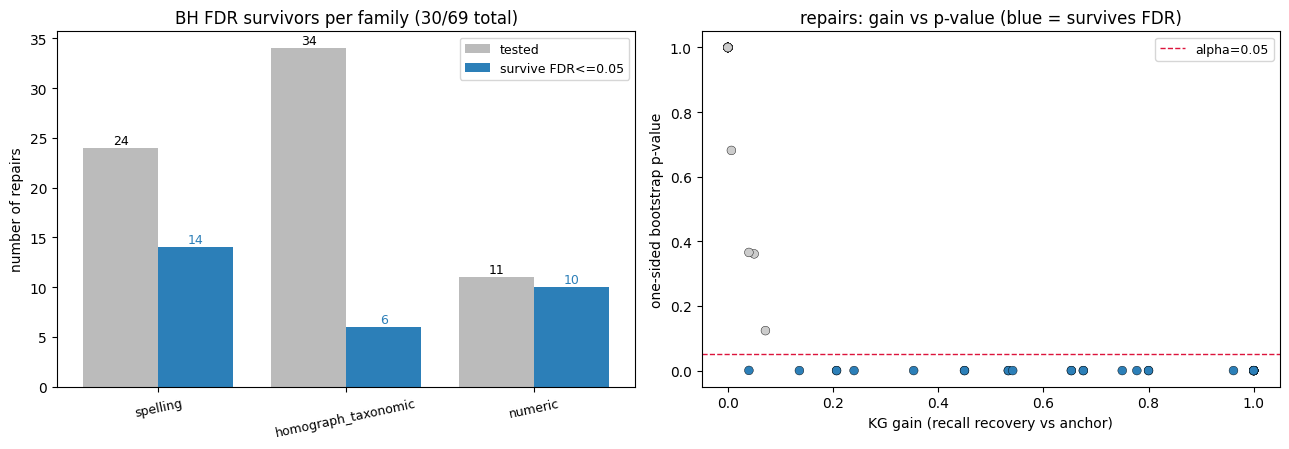


VERDICT (reproduced):
  kg_utility_measured       = True
  n_survive_FDR05           = 30
  per_family_survive_FDR    = {'spelling': 14, 'homograph_taxonomic': 6, 'numeric': 10}
  mean KG-gain (survivors)  = 0.6813 CI excludes 0: True


In [10]:
# ---- summary table of FDR survivors (sorted by gain) ----
surv_rows = [(r["metadata_concept"], r["metadata_subcontext"], r["metadata_variant"],
              r["metadata_gain_kg"], r["metadata_p_value"], q[i])
             for i, r in enumerate(rows) if survives_FDR[i]]
surv_rows.sort(key=lambda t: -t[3])
print(f"{'concept':<16}{'sub-context':<14}{'variant':<14}{'gain_kg':>8}{'p':>9}{'bh_q':>9}")
print("-" * 70)
for c, x, v, g, p, qq in surv_rows[:20]:
    print(f"{c:<16}{str(x):<14}{v:<14}{g:>8.3f}{p:>9.4f}{qq:>9.4f}")
print(f"... ({len(surv_rows)} survivors total)")

# ---- plots ----
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))

famnames = ["spelling", "homograph_taxonomic", "numeric"]
tested = [fam[f] for f in famnames]
sig    = [fam_sig[f] for f in famnames]
xp = np.arange(len(famnames))
ax[0].bar(xp - 0.2, tested, 0.4, label="tested", color="#bbbbbb")
ax[0].bar(xp + 0.2, sig,    0.4, label="survive FDR<=0.05", color="#2c7fb8")
for i, (t, s) in enumerate(zip(tested, sig)):
    ax[0].text(i - 0.2, t + 0.4, str(t), ha="center", fontsize=9)
    ax[0].text(i + 0.2, s + 0.4, str(s), ha="center", fontsize=9, color="#2c7fb8")
ax[0].set_xticks(xp); ax[0].set_xticklabels(famnames, rotation=12, fontsize=9)
ax[0].set_ylabel("number of repairs")
ax[0].set_title(f"BH FDR survivors per family ({n_sig}/{len(rows)} total)")
ax[0].legend(fontsize=9)

colors = np.where(survives_FDR, "#2c7fb8", "#cccccc")
ax[1].scatter(gains, pvals, c=colors, edgecolor="k", linewidth=0.3, s=40)
ax[1].axhline(FDR_ALPHA, ls="--", c="crimson", lw=1, label=f"alpha={FDR_ALPHA}")
ax[1].set_xlabel("KG gain (recall recovery vs anchor)")
ax[1].set_ylabel("one-sided bootstrap p-value")
ax[1].set_title("repairs: gain vs p-value (blue = survives FDR)")
ax[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print("\nVERDICT (reproduced):")
print("  kg_utility_measured       =", bool(n_sig >= 1))
print("  n_survive_FDR05           =", n_sig)
print("  per_family_survive_FDR    =", fam_sig)
print("  mean KG-gain (survivors)  =", round(agg_surv["diff"], 4),
      "CI excludes 0:", agg_surv["excl_0"])